[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Humboldt-TheoLab/computational_philology/blob/main/exercices/01_Intro_to_jupyter_notebook.ipynb)

This notebook is adapted from [Introduction to Jupyter Notebooks](https://github.com/Humboldt-WI/IPML/blob/main/tutorial_notebooks/1_jupyter_notebook_intro.ipynb) by Prof. Dr. Stefan Lessmann, Humboldt-WI, published under the [MIT](https://opensource.org/licenses/MIT) license. Modifications and additions: Prof. Dr. Frédérique Rey, 2026.

# This is a Jupyter Notebook
<hr>

It allows you to write text, format that text using, e.g., **bold** or *italic* face, create bullet  <br>

- A
    - a
    - b
    - c
- B
- C

and numbered lists <br>
1. First
2. Second
3. Third

and much more.

**Just double-click a cell to see the underlying "source code", which you can easily edit.**

You can also organize your text/notebook using headers
# Header 1
## Header 2
### Header 3
#### Header 4

You can also include links to your favorite websites, such as our [GitHub repository](https://github.com/Humboldt-WI). 


> **These cells are encoded in *markdown* language. You can find documentation on the syntax [here](https://www.markdownguide.org/basic-syntax/).**


# So what about programming?

Indeed, a notebook is more than a basic text editor. The real purpose of a notebook is to mix text with Python codes. Below is an example of a `code cell`. You can execute the code by moving the mouse cursor into the code cell and then clicking the **play button** in the command bar. Afterwards, the output of the code (if any) will be incorporated into your notebook right below the code cell.


In [ ]:
message = "Hello World"
print(message)

Now try to run the next code cell.

In [ ]:
# This is also a code cell. Try to execute it.
"""
This is also a code cell.
Try to execute it.
"""

No output from this code :(

Any line preceded by a hashtag is ignored by the interpreter. This allows **comments** to be inserted.
Anything between three quotation marks """ """ is ignored by the interpreter. This allows multi-line comments to be inserted.

In [ ]:
# Basic demo to using Python 
message = "Hello World (again)"  # here, we define a variable that stores some text
print(message)  # the function print() will - surprise - print out its argument, which we supply within the brackets

# Well, this does not impress me much

Indeed, printing a "Hello World" message is not very impressive. But Python's strength lies in its ability to import libraries that have already been pre-coded for you and use them. For example, run the following cell.

In [3]:
import matplotlib.pyplot as plt
import numpy as np

This cell does not produce anything in itself, but loads the two libraries matplotlib and numpy.

Now execute the following cell.

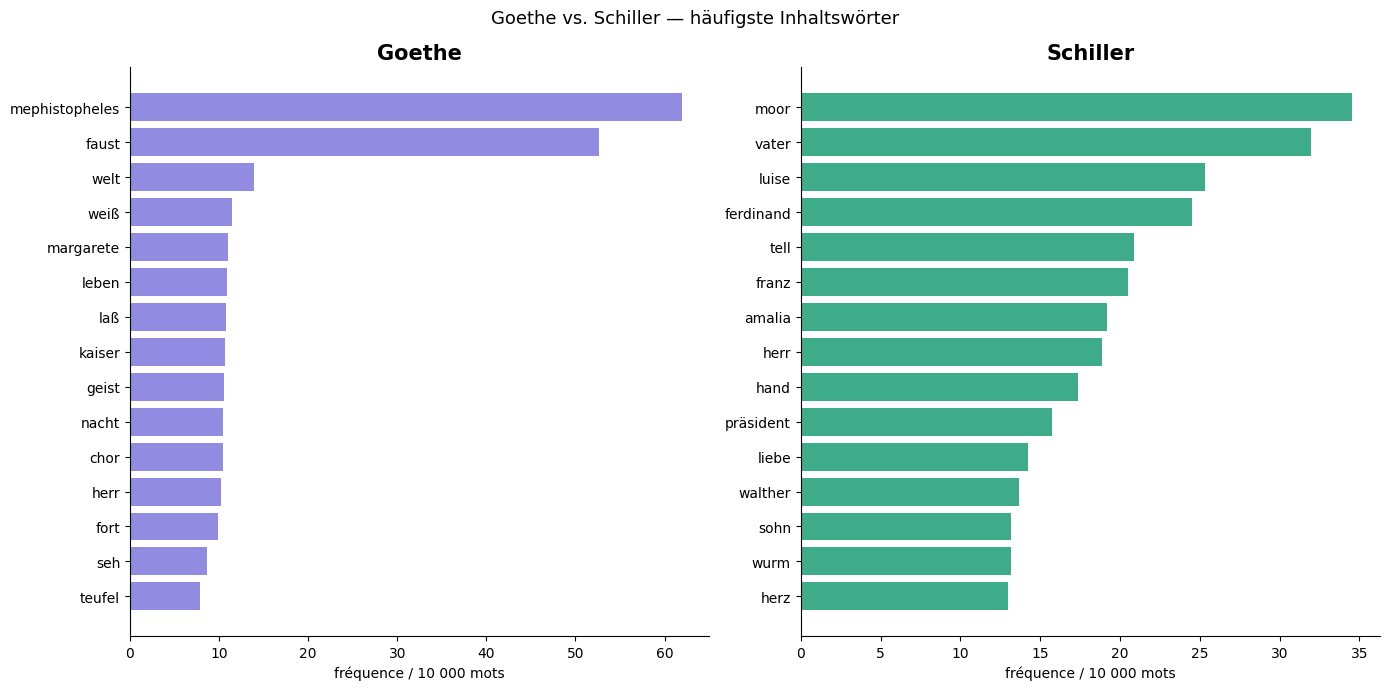

In [4]:
import urllib.request, re
from collections import Counter

# Upload a list of stop words in German
SW = set(urllib.request.urlopen("https://raw.githubusercontent.com/stopwords-iso/stopwords-de/master/stopwords-de.txt").read().decode().splitlines())

# Uploads URLs of works in txt format
URLS = {
    "Goethe":   ["https://www.gutenberg.org/cache/epub/2229/pg2229.txt", # Fauts I
                 "https://gutenberg.org/cache/epub/2230/pg2230.txt", # Faust II
                 "https://gutenberg.org/files/19794/19794.txt"], # Die Leiden des jungen Werther
    "Schiller": ["https://gutenberg.org/cache/epub/47804/pg47804.txt", # Die Räuber
                 "https://gutenberg.org/cache/epub/6498/pg6498.txt", # Kabale und Liebe
                 "https://gutenberg.org/cache/epub/77182/pg77182.txt"], # Wilhelm Tell
}

def charger(url):
    # This function returns the complete text of a work.
    t = urllib.request.urlopen(url).read().decode("utf-8", errors="ignore")
    return t[t.find("*** START OF"):t.find("*** END OF")]

def top(texte, n=15):
    # This function returns a list of the 15 (n) most frequent words and their corresponding frequencies.
    mots = [m for m in re.findall(r'\b[a-zA-ZäöüÄÖÜß]+\b', texte.lower()) if m not in SW]
    return zip(*Counter(mots).most_common(n))

corpus = {a: " ".join(charger(u) for u in urls) for a, urls in URLS.items()} # stores in "corpus" a dictionary with the author's name and all the words used

# Plot the graph using the matplotlib library
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, (auteur, texte) in zip(axes, corpus.items()):
    mots, freqs = top(texte)
    ax.barh(mots, np.array(freqs) / len(texte.split()) * 10_000,
            color={"Goethe":"#7F77DD","Schiller":"#1D9E75"}[auteur], alpha=.85)
    ax.set_title(auteur, fontsize=15, fontweight="bold")
    ax.set_xlabel("fréquence / 10 000 mots")
    ax.invert_yaxis()
    [ax.spines[s].set_visible(False) for s in ("top","right")]

plt.suptitle("Goethe vs. Schiller — häufigste Inhaltswörter", fontsize=13)
plt.tight_layout(); plt.show()

In just a few lines of code, Python loaded three works by Goethe: Faust I, Faust II, and Die Leiden des jungen Werther, as well as three works by Schiller: Die Räuber, Kabale und Liebe, and Wilhelm Tell. It counts the number of occurrences of all words, retains the 15 most frequent ones, and plots a bar chart of the results.

The point is not so much the code itself as the computing power and ability to transform these results into a graph.

Run the following cell to see another visualization of the data.

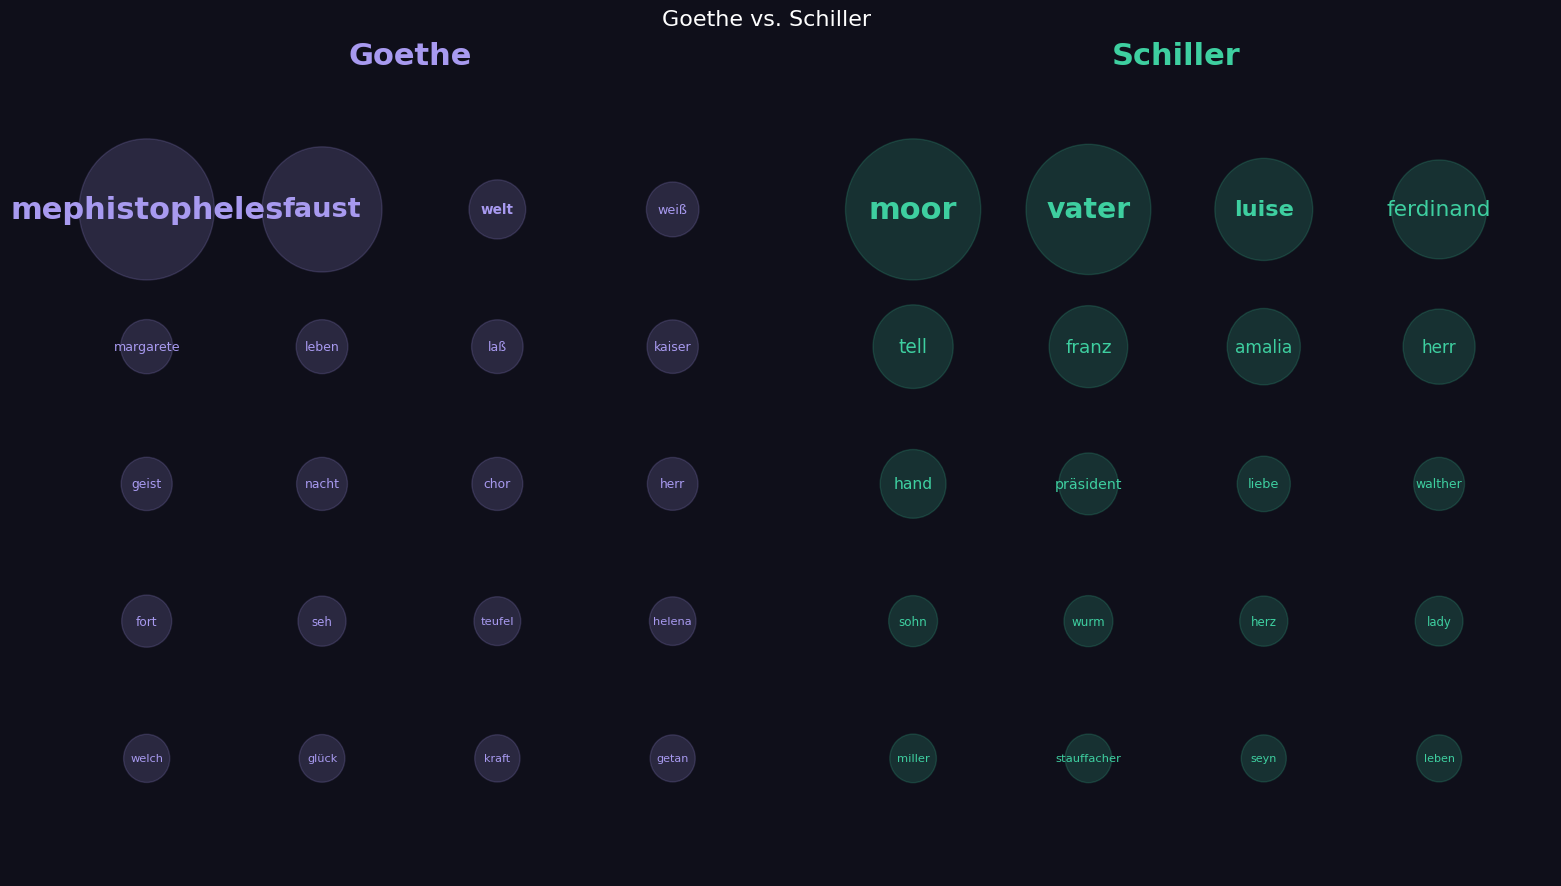

In [6]:
def plot_bulles(corpus, n=20):
    fig, axes = plt.subplots(1, 2, figsize=(16, 9), facecolor="#0f0f1a")
    couleurs = {"Goethe": "#a89af0", "Schiller": "#3ecfa0"}

    for ax, (auteur, texte) in zip(axes, corpus.items()):
        mots_top, freqs_raw = top(texte, n)
        paires = list(zip(mots_top, freqs_raw))
        freqs  = np.array(freqs_raw, dtype=float)
        fn     = (freqs - freqs.min()) / (freqs.max() - freqs.min())
        pos    = [(x, y) for y in np.linspace(.85,.15,5) for x in np.linspace(.15,.85,4)]

        ax.set(xlim=(0,1), ylim=(0,1), facecolor="#0f0f1a")
        ax.axis("off")
        ax.set_title(auteur, fontsize=22, fontweight="bold", color=couleurs[auteur], pad=20)

        for i, ((mot, freq), (px, py), s) in enumerate(zip(paires, pos, fn)):
            ax.add_patch(plt.Circle((px, py), .03 + s*.06, color=couleurs[auteur], alpha=.18))
            ax.text(px, py, mot, ha="center", va="center",
                    fontsize=8 + s*14, color=couleurs[auteur],
                    fontweight="bold" if i < 3 else "normal")

    fig.suptitle("Goethe vs. Schiller", fontsize=16, color="white")
    plt.tight_layout(); plt.show()

plot_bulles(corpus)


The library we used for the above example `matplotlib` comes with a [comprehensive documentation](https://matplotlib.org/), which tells you everything you might want to know. One nice feature of the documentation is that it has many examples. Check out the [website](https://matplotlib.org/), click on **Examples**, pick one of the exemplary plots - just pick whichever you like best - and copy & paste the Python code into the below code cell. Then run it to create another plot. 

# I'm am still not impressed
Ok, if you are one of the more demanding characters let us examine what happens if we combine Python, notebooks, and **GenAI**.

I guess you have heard about Claude from Anthropic. Did you know that it is quite fluent in Python? It is.

Here is a prompt you could try but feel free to adjust it and try out different ways of prompting Claude to generate Python code for creating a collation of Greek or Latin manuscripts
```

Please, write a Python code that compares the verse of n manuscripts given as input in a JSON file and creates an alignment table and a distance matrix.
It must be a single cell that can be copied and pasted into a Jupyter notebook without having to install any special libraries, and that runs directly and independently.

JSON example (Mark 1:1)
{
  "01":   "αρχη του ευαγγελιου ιυ χυ",
  "03":   "αρχη του ευαγγελιου ιυ χυ υιου θυ",
  "037":  "αρχη του ευαγγελιου ιυ χυ υιου του θυ",
  "1241": "αρχη του ευαγγελιου ιυ χυ υιου του κυ"
}

```

In [ ]:
# Empty code cell to which you can copy-paste ChatGPT output